In [221]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import matplotlib.cm as cm
import json
import re

from node2vec import Node2Vec

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,TensorDataset, Subset

from random import randint, choice



DEBUG = True
RAW_DATA_PATH = 'Sim_Raw_data.parquet'
GRAPH_DATA_PATH = 'Sim_Graph.json'

DIR_TRAINED = "TRAINED_MODELS"

SAMPLING = '120min'
SAMPLING_MIN = 120
MONTHS_HISTORY = 8

# CREATION GRAPH

In [222]:
with open(GRAPH_DATA_PATH, 'r') as f:
    G_router_json = json.load(f)

G_router = nx.node_link_graph(G_router_json)


NODE_LIST = list(G_router.nodes())
EDGE_LIST = list(G_router.edges())
NUM_NODES = len(NODE_LIST)
NUM_EDGES = len(EDGE_LIST)

print("NUmber of nodes: ", NUM_NODES)
print("NUmber of edges: ", NUM_EDGES)
print(f"NODE_LIST: {NODE_LIST} ")
print(f"EDGE_LIST: {EDGE_LIST}")

NODE_TO_IDX = {node: idx for idx, node in enumerate(NODE_LIST)}
IDX_TO_NODE = {idx: node for idx, node in enumerate(NODE_LIST)}

INNER_MASK = [x for x in NODE_LIST]

NUmber of nodes:  16
NUmber of edges:  16
NODE_LIST: ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4'] 
EDGE_LIST: [('HR_A', 'MR_A'), ('MR_A', 'C'), ('HR_B', 'MR_B'), ('MR_B', 'MR_A'), ('MR_B', 'A'), ('C', 'D'), ('C', 'S7'), ('D', 'E'), ('D', 'S6'), ('D', 'S5'), ('A', 'B'), ('A', 'S1'), ('A', 'S2'), ('B', 'D'), ('B', 'S3'), ('E', 'S4')]


# DATA PREPARATION

In [223]:
DATA_RAW_MODEL = pd.read_parquet(RAW_DATA_PATH)
DATA_RAW_MODEL = DATA_RAW_MODEL.resample(SAMPLING).mean()

## 8 Months history
DATA_RAW_MODEL = DATA_RAW_MODEL[DATA_RAW_MODEL.index.month.isin(DATA_RAW_MODEL.index.month.unique()[-MONTHS_HISTORY:])]
DATA_RAW_MODEL = DATA_RAW_MODEL.round(2)
DATA_RAW_MODEL = DATA_RAW_MODEL[NODE_LIST]

display(DATA_RAW_MODEL)


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
2024-01-01 00:00:00,77.30,77.30,214.12,214.12,77.30,73.85,136.81,80.63,58.97,3.45,13.78,1.10,6.78,54.71,1.47,58.97
2024-01-01 02:00:00,71.19,71.19,198.33,198.33,71.19,67.70,127.14,75.40,52.55,3.49,15.15,0.00,7.71,50.19,1.55,52.55
2024-01-01 04:00:00,69.21,69.21,188.16,188.16,69.21,65.56,118.95,72.19,53.91,3.65,11.37,0.28,6.63,45.40,1.36,53.91
2024-01-01 06:00:00,70.72,70.72,193.59,193.59,70.72,68.42,122.87,73.37,51.08,2.30,14.31,3.03,4.96,48.26,1.24,51.08
2024-01-01 08:00:00,84.27,84.27,241.03,241.03,84.27,80.98,156.76,87.24,52.82,3.29,19.63,8.53,6.26,68.17,1.35,52.82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-06-28 14:00:00,348.34,348.34,1019.93,1019.93,348.34,335.18,671.59,384.78,181.28,13.15,46.54,107.37,49.60,281.09,5.72,181.28
2024-06-28 16:00:00,687.24,687.24,2044.18,2044.18,687.24,657.34,1356.93,761.35,351.98,29.91,101.48,203.88,104.01,582.94,12.64,351.98
2024-06-28 18:00:00,931.89,931.89,2708.43,2708.43,931.89,888.45,1776.53,1029.47,472.33,43.45,144.57,271.55,141.02,731.39,15.68,472.33
2024-06-28 20:00:00,790.27,790.27,2262.58,2262.58,790.27,752.46,1472.31,875.43,412.19,37.81,120.38,219.88,122.97,582.61,14.26,412.19


# GMAN MATRICES

## ADJACENCY MATRIX

In [224]:
def get_line_adjacency_matrix(G, NODE_LIST):
    """
    Returns the adjacency matrix of G_line as a numpy array, 
    preserving the order specified in NODE_LIST.
    """
    return nx.to_numpy_array(G, nodelist=NODE_LIST)

ADJ_MATRIX = get_line_adjacency_matrix(G_router, NODE_LIST)
ADJ_MATRIX_DF = pd.DataFrame(ADJ_MATRIX, columns=NODE_LIST, index=NODE_LIST).astype(int)
print("Adjacency Matrix:")
ADJ_MATRIX_DF

Adjacency Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
MR_A,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0
HR_B,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
MR_B,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
C,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
D,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,0
A,0,0,0,0,0,0,0,1,0,0,0,0,0,1,1,0
B,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0
E,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
S7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## INCIDENCE MATRIX

In [225]:
def build_node_conservation_matrix(G, node_list):
    """
    Constructs a matrix where every row represents a Conservation Equation:
    Equation: Flow(Parent) - Sum(Flow(Children)) = 0
    
    Args:
        G (nx.DiGraph): The network topology.
        node_list (list): List of node names in the exact order of your data columns.
        
    Returns:
        np.ndarray: Matrix of shape [Num_Constraints, Num_Nodes]
        list: Labels for the rows (which Parent node each row represents)
    """
    node_to_idx = {n: i for i, n in enumerate(node_list)}
    num_nodes = len(node_list)
    
    constraints = []
    row_labels = [] 
    
    # Iterate over every node to see if it acts as a Parent (Source/Router)
    for parent in G.nodes():
        children = list(G.successors(parent))
        
        # If it has no children (Sink), there is no downstream flow to check
        if len(children) == 0:
            continue
            
        # Create a row of zeros
        row = np.zeros(num_nodes)
        
        # 1. The Parent (Source of flow) is Positive (+1)
        if parent in node_to_idx:
            row[node_to_idx[parent]] = 1.0
            
        # 2. The Children (Destination of flow) are Negative (-1)
        for child in children:
            if child in node_to_idx:
                row[node_to_idx[child]] = -1.0
                
        constraints.append(row)
        row_labels.append(parent)
        
    if not constraints:
        print("⚠️ Warning: No parent-child relationships found in Graph.")
        return np.zeros((0, num_nodes)), []

    # Stack into a single Matrix
    matrix = np.vstack(constraints)
    
    print(f"✅ Conservation Matrix Built: {matrix.shape}")
    print(f"   (Checking {matrix.shape[0]} Parent->Children groups)")
    
    return matrix, row_labels

INCIDENCE_MATRIX, row_labels = build_node_conservation_matrix(G_router, NODE_LIST)
INCIDENCE_MATRIX_DF = pd.DataFrame(INCIDENCE_MATRIX, columns=NODE_LIST, index=row_labels)
print("Incidence Matrix:")
display(INCIDENCE_MATRIX_DF)

if DEBUG:
    _flow_kirchoffs_test = []
    for _ in range(100):
        _test_flow = DATA_RAW_MODEL.sample(1)
        _flow = np.dot(INCIDENCE_MATRIX, _test_flow.T.values)
        _flow_kirchoffs_test.append(_flow.sum())
    
    print("The average loss is: {}".format(np.mean(_flow_kirchoffs_test)))

✅ Conservation Matrix Built: (9, 16)
   (Checking 9 Parent->Children groups)
Incidence Matrix:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_A,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
HR_B,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
MR_B,0.0,-1.0,0.0,1.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0
D,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,0.0,0.0
A,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,0.0,-1.0,-1.0,0.0
B,0.0,0.0,0.0,0.0,0.0,-1.0,0.0,1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0
E,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-1.0


The average loss is: 0.000400000000010208


## NODE MASKS

In [226]:
INNER_NODES_MASK =  (INCIDENCE_MATRIX_DF == 1).sum()
LEAF_NODES_MASK = (INNER_NODES_MASK == 0)*1

LEAF_INDICES = [i for i,x in enumerate(NODE_LIST) if LEAF_NODES_MASK.values[i] == 1]
INNER_INDICES = [i for i,x in enumerate(NODE_LIST) if INNER_NODES_MASK.values[i] == 1]
print(f"INNER_NODES_MASK: {INNER_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if INNER_NODES_MASK.iloc[i]])
print()
print(f"LEAF_NODES_MASK: {LEAF_NODES_MASK.values}")
print([x for i,x in enumerate(NODE_LIST) if LEAF_NODES_MASK.iloc[i]])


print(LEAF_INDICES)
print(INNER_INDICES)

INNER_NODES_MASK: [1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0]
['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']

LEAF_NODES_MASK: [0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]
['S7', 'S6', 'S5', 'S3', 'S1', 'S2', 'S4']
[9, 10, 11, 12, 13, 14, 15]
[0, 1, 2, 3, 4, 5, 6, 7, 8]


## MASK ATTENTION MASK

In [227]:
def generate_node_reconstruction_mask_numpy(G_physical, node_list, k_hops=1):
    """
    Generates a Node-to-Node Spatial Attention Mask as a NumPy array.
    
    Args:
        G_physical (nx.DiGraph): The router-to-router graph.
        node_list (list): The EXACT list of nodes in the desired order. 
        k_hops (int): Depth of vision (how far downstream to look).
        
    Returns:
        np.ndarray: Shape [N, N], dtype=bool.
                    True  = Blocked / Masked (Cannot attend).
                    False = Visible / Allowed (Can attend).
    """
    num_nodes = len(node_list)
    print(f"--- Generating Ordered Node Mask (NumPy) ---")
    
    # 1. Create Mapping
    # Ensures Row 0 is node_list[0], Row 1 is node_list[1]...
    node_to_idx = {node: i for i, node in enumerate(node_list)}
    
    # 2. Initialize Mask
    # Default is True (Blocked/Hidden)
    mask = np.ones((num_nodes, num_nodes), dtype=bool)
    
    # 3. Build Connectivity
    for i, u in enumerate(node_list):
        
        if u not in G_physical:
            print(f"⚠️ Warning: Node '{u}' not found in graph.")
            continue
            
        # A. Self-Attention (Always Allow)
            mask[i, i] = False

        
        # B. Downstream Lookup
        try:
            # Find all nodes 'v' reachable from 'u' within k_hops
            descendants = nx.single_source_shortest_path_length(G_physical, u, cutoff=k_hops)
            
            for v in descendants:
                if v in node_to_idx:
                    j = node_to_idx[v]
                    mask[i, j] = False # Make visible
            
            #if re.match(r'S\d+', u):
            #    mask[i, i] = False
            #else:
            #    mask[i, i] = True 
                    
        except Exception as e:
            print(f"Error processing node {u}: {e}")

   
    # Stats
    total_cells = num_nodes * num_nodes
    visible_cells = (~mask).sum() # Count False values
    print(f"✅ Mask Created. Shape ({num_nodes}, {num_nodes}). Visible Connections: {visible_cells}")
    
    return mask

NODE_LIST_IDX = {x:i for i,x in enumerate(NODE_LIST)}
ATT_MASK = generate_node_reconstruction_mask_numpy(G_router, NODE_LIST, k_hops=1)

for node_idx in ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E']:
    ATT_MASK[NODE_LIST_IDX[node_idx], NODE_LIST_IDX[node_idx]] = True

ATT_MASK_DF = pd.DataFrame(ATT_MASK, columns=NODE_LIST, index=NODE_LIST)*1
print("Reconstruction Attention Mask:")

ATT_MASK_T = torch.tensor(ATT_MASK).to(torch.bool)

ATT_MASK_DF



ATT_MASK_DF = pd.DataFrame(np.zeros((16, 16), dtype=bool), columns=NODE_LIST, index=NODE_LIST)
for node_idx in ['HR_A', 'MR_A', 'HR_B', 'MR_B', 'C', 'D', 'A', 'B', 'E', 'S1','S2','S3','S4','S5','S6','S7']:
    ATT_MASK_DF.loc[node_idx,node_idx] = True


display(ATT_MASK_DF)
ATT_MASK_T = torch.tensor(ATT_MASK_DF.values).to(torch.bool)


--- Generating Ordered Node Mask (NumPy) ---
✅ Mask Created. Shape (16, 16). Visible Connections: 32
Reconstruction Attention Mask:


,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
MR_A,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
HR_B,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False
MR_B,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
C,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
D,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
A,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
B,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False
E,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False
S7,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False


### ATT MASK 2

In [228]:
LEAF_INDICES

[9, 10, 11, 12, 13, 14, 15]

In [229]:
def create_adjacency_mask(adjacency_matrix, penalty=-1e9):
    """
    Converts a binary adjacency matrix into an additive attention mask.
    adjacency_matrix: (16, 16) tensor where 1 = connected, 0 = disconnected.
    """
    # Initialize a mask heavily penalizing all connections
    mask = torch.full_like(adjacency_matrix, penalty, dtype=torch.float32)
    
    # Ensure every node can attend to itself (add self-loops if missing)
    eye = torch.eye(adjacency_matrix.size(0), device=adjacency_matrix.device)
    adj_with_self_loops = torch.clamp(adjacency_matrix + eye, max=1.0)
    
    # Where nodes are connected, remove the penalty (set to 0.0)
    mask = torch.where(adj_with_self_loops > 0, torch.zeros_like(mask), mask)
    
    # The resulting mask is (16, 16) and ready for the Transformer
    return mask


#### PARCHEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEEE #######################################
ATT_MASK_T = create_adjacency_mask( torch.tensor(nx.to_numpy_array(G_router)))
ATT_MASK_T[INNER_INDICES,INNER_INDICES] = float(-1000000000.0)


pd.DataFrame( ATT_MASK_T.numpy(), columns=NODE_LIST, index=NODE_LIST).astype(int)



,HR_A,MR_A,HR_B,MR_B,C,D,A,B,E,S7,S6,S5,S3,S1,S2,S4
HR_A,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
MR_A,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
HR_B,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
MR_B,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
C,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000
D,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,0,0,-1000000000,-1000000000,-1000000000,-1000000000
A,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,0,-1000000000
B,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000
E,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0
S7,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,0,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000,-1000000000


# PARAMETERS

In [230]:
# TRAINING PARAMS
BATCH_SIZE = 32
EPOCHS = 30
LR = 0.001

# DATASET PARAMS
#FREQ_H = int(re.search(r'[a-z]*(\d+)[a-z]*', SAMPLING)[1])
#FREQ_MINUTES = FREQ_H*60

NUM_NODES = len(NODE_LIST)
HIST_STEPS = int(1*(24*60/SAMPLING_MIN))          # 1 day
PRED_STEPS = int(1*(24*60/SAMPLING_MIN))          # 1 day
INPUT_DIM = 1
OUTPUT_DIM = 1
D_MODEL = 256

STEPS_PER_DAY = int(24*60/SAMPLING_MIN)
DAYS_PER_WEEK = 7
MONTHS_PER_YEAR = 12


TIME_FEATURES = STEPS_PER_DAY + DAYS_PER_WEEK + MONTHS_PER_YEAR 

LAYERS_ENC_DEC = 3
K_HEADS = 8
D_HEADS = int(D_MODEL/K_HEADS)

print(f"Frequency: {SAMPLING_MIN} minutes")
print(f"Number of nodes: {NUM_NODES}")
print(f"Number of historical steps: {HIST_STEPS}")
print(f"Number of prediction steps: {PRED_STEPS}")
print(f"Number of time features: {TIME_FEATURES}")
print(f"Input dimension: {INPUT_DIM}")
print(f"Output dimension: {OUTPUT_DIM}")
print(f"Model dimension: {D_MODEL}")
print(f"Steps per day: {STEPS_PER_DAY}")
print(f"Days per week: {DAYS_PER_WEEK}")
print(f"Months per year: {MONTHS_PER_YEAR}")
print(f"Layers encoder-decoder: {LAYERS_ENC_DEC}")
print(f"Number of heads: {K_HEADS}")
print(f"Dimension of each head: {D_HEADS}")

Frequency: 120 minutes
Number of nodes: 16
Number of historical steps: 12
Number of prediction steps: 12
Number of time features: 31
Input dimension: 1
Output dimension: 1
Model dimension: 256
Steps per day: 12
Days per week: 7
Months per year: 12
Layers encoder-decoder: 3
Number of heads: 8
Dimension of each head: 32


# DATASETS / DATALOADERS

In [231]:

import torch
from torch.utils.data import Dataset, DataLoader

class SlidingWindowSensorDataset(Dataset):
    def __init__(self, raw_time_series, known_sensor_indices, window_size=24, stride=1):
        """
        raw_time_series: Tensor of shape (Total_Time_Steps, 16)
        known_sensor_indices: List of the 7 fixed sensor indices
        seq_len: The number of time steps to look at (24)
        stride: How many steps to jump forward for the next sample. 
                stride=1 gives maximum data (high overlap).
                stride=24 gives zero overlap.
        """
        self.data = raw_time_series
        self.window_size = window_size
        self.stride = stride
        
        # Setup static masks
        self.known_indices = torch.tensor(known_sensor_indices, dtype=torch.long)
        num_total_sensors = raw_time_series.shape[1]
        
        all_indices = torch.arange(num_total_sensors)
        self.missing_indices = all_indices[~torch.isin(all_indices, self.known_indices)]
        
        self.missing_mask = torch.zeros(num_total_sensors, dtype=torch.bool)
        self.missing_mask[self.missing_indices] = True

    def __len__(self):
        # Calculate how many full windows we can extract
        return (self.data.shape[0] - self.window_size) // self.stride + 1

    def __getitem__(self, idx):
        # 1. Calculate the actual start and end index in the continuous data
        start_idx = idx * self.stride
        end_idx = start_idx + self.window_size
        
        # 2. Slice the 24-step window. Shape is currently (24, 16)
        window = self.data[start_idx:end_idx].clone()
        
        # 3. Transpose to match the model's expected shape: (16, 24)
        target_y = window.t()
        
        # 4. Create the input by masking the missing sensors to 0.0
        masked_x = target_y.clone()
        masked_x[self.missing_indices, :] = 0.0
        
        return masked_x.float(), target_y.float(), self.missing_mask




total_samples = len(DATA_RAW_MODEL)
print(f"Total valid sliding windows: {total_samples}")

train_size = int(total_samples * 0.8)
val_size = total_samples - train_size


train_data = torch.tensor(DATA_RAW_MODEL[:train_size].copy().values)
val_data = torch.tensor(DATA_RAW_MODEL[train_size:].copy().values)

TSS_TRAIN_DS = SlidingWindowSensorDataset(train_data, LEAF_INDICES, HIST_STEPS)
TSS_VAL_DS = SlidingWindowSensorDataset(val_data, LEAF_INDICES, HIST_STEPS)

print(f"Train size: {len(TSS_TRAIN_DS)}")
print(f"Val size: {len(TSS_VAL_DS)}")



TSS_TRAIN_DL = DataLoader(TSS_TRAIN_DS, batch_size=BATCH_SIZE, shuffle=True)
TSS_VAL_DL = DataLoader(TSS_VAL_DS, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(TSS_TRAIN_DL)} | Val samples: {len(TSS_VAL_DL)}")

if DEBUG:
    from random import randint

    _rand_idx = randint(0,len(TSS_TRAIN_DS))
    print()
    print(f"Random index: {_rand_idx}")
    X_real = DATA_RAW_MODEL.values[_rand_idx]
    print()
    print("X real:")
    print(X_real)

    _sample = TSS_TRAIN_DS[_rand_idx]

    X_masked = _sample[0]
    Y_real = _sample[1]
    _mask = _sample[2]
    print(f"X masked: {X_masked.shape}")
    print(X_masked[-1])
    print()
    print(f"Y real: {Y_real.shape}")
    print(Y_real[-1])

    print(f"Mask: {_mask}")

    print()
    for X_d, Y_real,_mask in TSS_TRAIN_DL:

        if randint(0,100) == 4:
            break

    print("#######################")
    print(_mask.shape)
    

 



Total valid sliding windows: 2160
Train size: 1717
Val size: 421
Train samples: 54 | Val samples: 14

Random index: 1657

X real:
[ 51.41  51.41 179.87 179.87  51.41  47.65 128.46  57.35  40.97   3.75
   6.38   0.3    9.7   69.77   1.34  40.97]
X masked: torch.Size([16, 12])
tensor([ 40.9700,  44.3300,  34.1400,  56.4900, 128.3100, 177.3400, 216.8700,
        438.5000, 575.1900, 484.7200, 611.4800,   1.8300])

Y real: torch.Size([16, 12])
tensor([ 40.9700,  44.3300,  34.1400,  56.4900, 128.3100, 177.3400, 216.8700,
        438.5000, 575.1900, 484.7200, 611.4800,   1.8300])
Mask: tensor([ True,  True,  True,  True,  True,  True,  True,  True,  True, False,
        False, False, False, False, False, False])

#######################
torch.Size([21, 16])


# MODEL
## ITransformer

In [232]:
import torch.nn as nn

class GraphBiasediTransformer(nn.Module):
    def __init__(self, num_nodes=16, time_steps=24, d_model=128, nhead=8, num_layers=3, dim_feedforward=512):
        super().__init__()
        
        # 1. Temporal embedding: Project 24 time steps to hidden dimension
        self.projector = nn.Linear(time_steps, d_model)
        
        # 2. Spatial embedding: Give each of the 16 sensors a strict physical identity
        self.node_embedding = nn.Parameter(torch.randn(1, num_nodes, d_model))
        
        self.layer_norm = nn.LayerNorm(d_model)
        
        # 3. Transformer Encoder configured for batch_first
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, 
            nhead=nhead, 
            dim_feedforward=dim_feedforward,
            batch_first=True,
            activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 4. Reconstruct the 24 time steps
        self.head = nn.Linear(d_model, time_steps)

    def forward(self, x, adj_mask):
        """
        x: (Batch, 16, 24) - The input time series (9 sensors masked to 0)
        adj_mask: (16, 16) - The additive topological bias
        """
        # Embed temporal data and inject the specific sensor's identity
        x_enc = self.projector(x) + self.node_embedding
        x_enc = self.layer_norm(x_enc)
        
        # Pass through the encoder, applying the structural graph mask.
        # This restricts information flow strictly to physical neighbors.
        enc_out = self.encoder(x_enc, mask=adj_mask)
        
        # Map back to standard time series domain
        reconstruction = self.head(enc_out)
        
        return reconstruction

if DEBUG:

    projector =  nn.Linear(HIST_STEPS , D_MODEL)
    node_embedding = nn.Parameter(torch.randn(1, NUM_NODES, D_MODEL))
    layer_norm = nn.LayerNorm(D_MODEL)

    encoder_layer = nn.TransformerEncoderLayer(
            d_model=D_MODEL, 
            nhead=K_HEADS, 
            dim_feedforward=512,
            batch_first=True,
            activation="gelu"
        )
    encoder = nn.TransformerEncoder(encoder_layer, num_layers=LAYERS_ENC_DEC)
    head = nn.Linear(D_MODEL, HIST_STEPS)

    for X_d, Y_d,_ in TSS_TRAIN_DL:
        if randint(0,10) == 4:
            break

    x_enc = projector(X_d) + node_embedding
    print(f"x_enc.shape: {x_enc.shape}")

    x_enc = layer_norm(x_enc)
    print(f"x_enc.shape: {x_enc.shape}")

    enc_out = encoder(x_enc, mask=ATT_MASK_T)
    print(f"enc_out.shape: {enc_out.shape}")

    reconstruction = head(enc_out)
    print(f"reconstruction.shape: {reconstruction.shape}")

    

x_enc.shape: torch.Size([32, 16, 256])
x_enc.shape: torch.Size([32, 16, 256])
enc_out.shape: torch.Size([32, 16, 256])
reconstruction.shape: torch.Size([32, 16, 12])


# TRAINNIG

In [233]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Training on: {DEVICE}")

Training on: cuda


### LOSS FUNCTION

In [289]:
import torch
import torch.nn.functional as F

INCIDENCE_MATRIX_T = torch.tensor(INCIDENCE_MATRIX, dtype=torch.float32)
INCIDENCE_MATRIX_T.shape

INNER_NODES_MASK_BOOL = INNER_NODES_MASK.astype(bool).values


def physics_informed_loss(predictions, targets, bool_mask, incidence_matrix, lambda_physics=0.1):
    """
    predictions: (Batch, 16, 24)
    targets: (Batch, 16, 24)
    bool_mask: (16,) True for the 9 masked sensors
    """
    # 1. Standard Data Loss (MSE on the 9 masked sensors)
    # Using the bool_mask to only calculate error on what was predicted
    mse_loss = F.mse_loss(predictions[:, bool_mask, :], targets[:, bool_mask, :])
    
    # 2. Physics Loss (Flow Conservation across ALL 16 sensors)
    # Recombine the 7 known sensors with the 9 predicted sensors to check total network balance
    full_network_state = targets.clone()
    full_network_state[:, bool_mask, :] = predictions[:, bool_mask, :]

    print(full_network_state.shape)
    
    # Calculate net flow at each node: Incidence Matrix * Network State
    # Ideally, for intermediate nodes, this should be very close to 0 (Flow In = Flow Out)
    # Equation: $\sum \text{flow}_{in} - \sum \text{flow}_{out} = 0$
    net_flow = torch.matmul(incidence_matrix, full_network_state)
    
    # The penalty is how far away the network is from perfect conservation
    physics_penalty = torch.mean(torch.abs(net_flow))
    
    # Combine the losses
    total_loss = mse_loss + (lambda_physics * physics_penalty)
    
    return total_loss, mse_loss,physics_penalty


def pinns_loss(predictions, targets, mask, incidence, lambda_phys=0.1):
    # 1. Data Loss: Mean Squared Error strictly on the 9 missing sensors
    # mask shape is (16,), indexing retrieves only the True (missing) sensors
    mse = F.mse_loss(predictions[:, mask, :], targets[:, mask, :])
    
    # 2. Reconstruct the full network state
    full_state = targets.clone()
    full_state[:, mask, :] = predictions[:, mask, :]
    
    # 3. Physics Loss: Kirchhoff's Flow Conservation
    # incidence: (Junctions, Sensors)
    # full_state: (Batch, Sensors, Time_Steps)
    # einsum maps this to calculate net flow at each Junction per Batch per Time_Step
    net_flow = torch.einsum('js,bst->bjt', incidence, full_state)
    
    # The physical penalty is the absolute deviation from zero net flow
    physics_penalty = torch.mean(torch.abs(net_flow))
    
    return mse + (lambda_phys * physics_penalty), mse, physics_penalty



class BottomUpReconstructionLoss(nn.Module):
    def __init__(self, G_physical, device='cpu'):
        super(BottomUpReconstructionLoss, self).__init__()
        
        # Adjacency: Rows=Parents, Cols=Children
        adj = nx.to_numpy_array(G_physical)
        adj_matrix = torch.tensor(adj, dtype=torch.float32).to(device)
      
        
        # Identify Parents (Nodes with outgoing edges/children)
        row_sum = adj_matrix.sum(dim=1)
        #self.parent_mask = (row_sum > 0).float().view(1, 1, -1).to(device)
        #self.parent_mask_bool = (row_sum > 0).to(device)

        self.register_buffer('parent_mask', (row_sum > 0).float().view(1, 1, -1))
        self.register_buffer('adj_matrix', adj_matrix)



    def forward(self, Y_pred_real, Y_true_real):
        # 1. Mix flows: Use Ground Truth for Leaves (Mask=1), Preds for Parents (Mask=0)
        # This propagates the "True" leaf traffic up to the parents
        
        #F_children = Y_pred_real
        # 2. Reshape for Matrix Mult: [Batch*Time, Nodes]

        mse_loss = F.mse_loss(Y_pred_real[:, :, :]*self.parent_mask, Y_true_real[:, :, :]*self.parent_mask)
        #B, T, C = F_children.shape
        #F_flat = F_children.reshape(B*T,C)
        
        # 3. Sum Children to find Expected Parent Flow
        # Parent_i = Sum(A_ij * Child_j) -> MatMul(F, A.T)
        #F_reconstructed_flat = torch.matmul(F_flat, self.adj_matrix.t())
        #F_reconstructed_flat = torch.matmul(self.adj_matrix, F_flat.T)
        #F_reference = F_reconstructed_flat.reshape(B, T, C)

        y_reconstructed= Y_pred_real @ self.adj_matrix.T
        y_parent_true = Y_true_real
        
        # 4. Compare: Does Model's Parent Prediction == Sum of Children?
        # Note: We compare against Y_pred_real (what the model thinks the parent is)
        #diff = Y_pred_real - F_reference
        #diff = Y_true_real - F_reference
        diff = y_parent_true - y_reconstructed

        
        # 5. Mask: Only punish Parent nodes (leaves don't have children to sum)
        #loss = diff.sum(dim=-1)**2
        phy_loss = (diff ** 2) * self.parent_mask
        phy_loss = phy_loss.mean()

        loss = mse_loss + phy_loss
        

        return loss, mse_loss, phy_loss
    
if DEBUG:
    print(INNER_NODES_MASK_BOOL)

    _flow_kirchoffs_test = []
    for _ in range(100):
        _test_flow = DATA_RAW_MODEL.sample(1)
        _flow = np.dot(INCIDENCE_MATRIX, _test_flow.T.values)
        _flow_kirchoffs_test.append(_flow.sum())
    
    print("The average loss is: {}".format(np.mean(_flow_kirchoffs_test)))

    print()

    for X_d, Y_real,_ in TSS_TRAIN_DL:

        if randint(0,100) == 4:
            break

    print(f"Y_real {Y_real.shape}")

    print(f" PIN LOSS")
    _loss_fn = pinns_loss(Y_real, Y_real, INNER_NODES_MASK_BOOL, INCIDENCE_MATRIX_T)
    print(_loss_fn)

    print(f" physics_informed_loss")
    _loss_fn = physics_informed_loss(Y_real, Y_real, INNER_NODES_MASK_BOOL, INCIDENCE_MATRIX_T)
    print(_loss_fn)

    print(f" bootom loss")
    _loss_fn = BottomUpReconstructionLoss(G_router)
    loss_bot = _loss_fn(Y_real.permute(0,2,1),Y_real.permute(0,2,1))
    print(loss_bot)



[ True  True  True  True  True  True  True  True  True False False False
 False False False False]
The average loss is: -0.001100000000023319

Y_real torch.Size([21, 16, 12])
 PIN LOSS
(tensor(0.0002), tensor(0.), tensor(0.0015))
 physics_informed_loss
torch.Size([21, 16, 12])
(tensor(0.0002), tensor(0.), tensor(0.0015))
 bootom loss
(tensor(8.5269e-06), tensor(0.), tensor(8.5269e-06))


In [290]:
MODEL = GraphBiasediTransformer(
    num_nodes=NUM_NODES, 
    time_steps=HIST_STEPS, 
    d_model=D_MODEL, 
    nhead=K_HEADS, 
    num_layers=LAYERS_ENC_DEC
).to(DEVICE)




PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim_2'
CHECKPOINT_PATH = f'{DIR_TRAINED}/best_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

optimizer = torch.optim.Adam(MODEL.parameters(), lr=LR) #LR)



Checkpoint path: TRAINED_MODELS/best_model_itransformer_att_phy_mask_node_sim_2.pth


### TRAINING

In [291]:
PATIENCE = 10

class EarlyStopping:
    def __init__(self, patience=5, verbose=True, delta=0, path='best_model.pth'):
        """
        Args:
            patience (int): How many epochs to wait after last time val_loss improved.
            verbose (bool): If True, prints a message for each validation loss improvement.
            delta (float): Minimum change in the monitored quantity to qualify as an improvement.
            path (str): Path for the checkpoint to be saved to.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Saves model when validation loss decreases.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

CHECKPOINT_PATH = f'{DIR_TRAINED}/best_early_{PREFIX_MODEL}.pth'
print(f"Checkpoint path: {CHECKPOINT_PATH}")

early_stopping = EarlyStopping(patience=PATIENCE, verbose=True, delta=0, path=CHECKPOINT_PATH)

Checkpoint path: TRAINED_MODELS/best_early_model_itransformer_att_phy_mask_node_sim_2.pth


In [292]:
MODEL.train()

loss_fn = BottomUpReconstructionLoss(G_router).to(DEVICE)
INNER_NODES_MASK_T = torch.tensor(INNER_NODES_MASK.astype(bool).values)


epoch_mse_loss_arr = []
epoch_phy_loss_arr = []

EPOCHS = 200
for epoch in range(EPOCHS):
    total_loss = 0.0
    total_mse = 0.0
    total_phys = 0.0
    
    for batch_x, batch_y, batch_mask in TSS_TRAIN_DL:
        # Move batch data to GPU/CPU
        batch_x = batch_x.to(DEVICE)
        batch_y = batch_y.to(DEVICE)
        # The mask is the same for every batch in this fixed-sensor setup, 
        # but we take the first one from the batch for indexing
        bool_mask = batch_mask[0].to(DEVICE) 
  
        
        optimizer.zero_grad()
        
        # Forward pass (injecting the graph structure via adj_mask)
        predictions = MODEL(x=batch_x, adj_mask=ATT_MASK_T.to(DEVICE))
        
        # Calculate dual-objective loss
        #loss, mse_val, phys_val = pinns_loss(
        #    predictions=predictions, 
        #    targets=batch_y, 
        #    mask=torch.tensor(INNER_NODES_MASK_BOOL).to(DEVICE), 
        #    incidence=INCIDENCE_MATRIX_T.to(DEVICE), 
        #    lambda_phys=1 # Adjust this weight based on priority
        #)
        loss, mse_val, phys_val  = loss_fn(predictions.permute(0,2,1),batch_y.permute(0,2,1))
        # Backpropagation
        loss.backward()
        
        # Gradient clipping is highly recommended for Transformer architectures
        torch.nn.utils.clip_grad_norm_(MODEL.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        total_mse += mse_val.item()
        total_phys += phys_val.item()
    
    # Early Stopping
    early_stopping(total_loss, MODEL)
    if early_stopping.early_stop:
        print("Early stopping triggered. Training stopped.")
        break

    # Load best model
    MODEL.load_state_dict(torch.load(CHECKPOINT_PATH))
    print("Best model weights loaded for testing.")


    
    epoch_mse_loss_arr.append(total_mse/len(TSS_TRAIN_DL))
    epoch_phy_loss_arr.append(total_phys/len(TSS_TRAIN_DL))

    # Logging metrics per epoch
    num_batches = len(TSS_TRAIN_DL)
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | "
          f"Total Loss: {total_loss/num_batches:.4f} | "
          f"MSE: {total_mse/num_batches:.4f} | "
          f"Physics: {total_phys/num_batches:.4f}")

OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'
torch.save(MODEL.state_dict(), OUTPUT_MODEL)
print(f"Model saved to {OUTPUT_MODEL}")

Validation loss decreased (inf --> 47226809.562500).  Saving model ...
Best model weights loaded for testing.
Epoch 001/200 | Total Loss: 874570.5475 | MSE: 439378.3553 | Physics: 435192.1892
Validation loss decreased (47226809.562500 --> 45736606.500000).  Saving model ...
Best model weights loaded for testing.
Epoch 002/200 | Total Loss: 846974.1944 | MSE: 429317.4554 | Physics: 417656.7419
Validation loss decreased (45736606.500000 --> 43953597.000000).  Saving model ...
Best model weights loaded for testing.
Epoch 003/200 | Total Loss: 813955.5000 | MSE: 416961.2483 | Physics: 396994.2494
Validation loss decreased (43953597.000000 --> 42028152.250000).  Saving model ...
Best model weights loaded for testing.
Epoch 004/200 | Total Loss: 778299.1157 | MSE: 403079.4716 | Physics: 375219.6470
Validation loss decreased (42028152.250000 --> 40081304.312500).  Saving model ...
Best model weights loaded for testing.
Epoch 005/200 | Total Loss: 742246.3762 | MSE: 388340.7778 | Physics: 3539

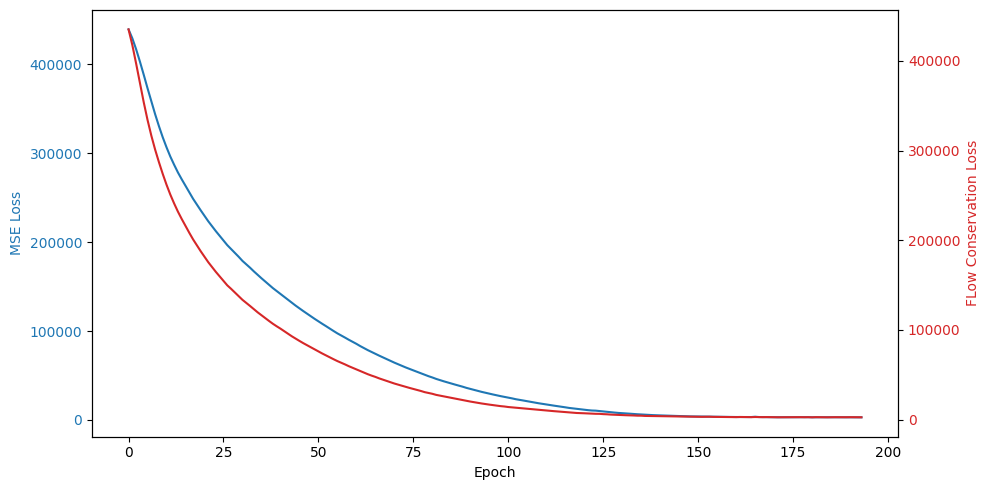

In [293]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss', color='tab:blue')
ax1.plot(epoch_mse_loss_arr, color='tab:blue', label='MSE Loss')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('FLow Conservation Loss', color='tab:red')
ax2.plot(epoch_phy_loss_arr, color='tab:red', label='FLow Conservation Loss')
ax2.tick_params(axis='y', labelcolor='tab:red')

fig.tight_layout()
plt.show()



### RECONSTRUCTION OF FLOWS

In [294]:
MODEL = GraphBiasediTransformer(
    num_nodes=NUM_NODES, 
    time_steps=HIST_STEPS, 
    d_model=D_MODEL, 
    nhead=K_HEADS, 
    num_layers=LAYERS_ENC_DEC
)



PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim_2'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)




Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_node_sim_2_trained.pth


<All keys matched successfully>

### VALIDATION

In [295]:
import math

def validate_model(model, dataloader, criterion, att_mask, device,  channel=None):
    """
    Validates the model and calculates Scaled Loss, Real MAE, and Real RMSE.
    """

    if channel is not None:
        print(f"Channel: {channel}")
    
    model.eval()
    
    total_scaled_loss = 0.0
    total_real_mae = 0.0
    total_real_mse = 0.0  
    

    # Disable gradient calculation for efficiency
    with torch.no_grad():
        for batch_idx, (X_masked, Y_true,_) in enumerate(dataloader):
            
            X_masked = X_masked.to(device)
            Y_true = Y_true.to(device)
            
            # Forward Pass
            Y_pred = model(x=X_masked, adj_mask=att_mask)
            
            # Calculate Scaled Loss (MSE for backprop monitoring)
            loss = criterion(Y_pred, Y_true)
            total_scaled_loss += loss.item()
            
 
            if channel is not None:
                Y_pred = Y_pred[:, :, channel]
                Y_true = Y_true[:, :, channel]
            
            mae = torch.mean(torch.abs(Y_pred - Y_true))
            total_real_mae += mae.item()
            
            mse_real = torch.mean((Y_pred - Y_true) ** 2)
            total_real_mse += mse_real.item()
            
    # Calculate averages over all batches
    avg_scaled_loss = total_scaled_loss / len(dataloader)
    avg_real_mae = total_real_mae / len(dataloader)
    avg_real_mse = total_real_mse / len(dataloader)
    
    # RMSE is the square root of the overall average MSE <-- ADDED
    avg_real_rmse = avg_real_mse ** 0.5
    
    return avg_scaled_loss, avg_real_mae, avg_real_rmse

def validate_plots(model, dataloader, scaler_mean, scaler_std, device, num_nodes_to_plot=3):
    import random
    """
    Takes a random batch from the dataloader, predicts, and plots the results.
    
    Args:
        model: Trained GMAN model.
        dataloader: Validation/Test DataLoader (Shuffle=True recommended for randomness).
        device: 'cuda' or 'cpu'.
        node_mode: Optional mask for heterogeneous nodes.
        num_nodes_to_plot: How many random nodes to visualize from the sample.
    """

    model.eval()
    means = torch.as_tensor(scaler_mean, device=device).float().view(1,1,-1)
    scale = torch.as_tensor(scaler_std, device=device).float().view(1,1,-1)


    
    # 1. Get a single batch
    # We use next(iter()) which grabs the first batch. 
    # If your loader has shuffle=True, this is random.
  
    X, Y_true_scaled = next(iter(dataloader))


    # Move to Device
    X = X.to(device)
    B,T,C = X.shape
    
    # 2. Inference
    with torch.no_grad():
        Y_pred_scaled = model(X)

    # 3. Inverse Transform (Get Real Units)
    # The dataset handles the math to get back to Gbps/Mbps

    Y_true_real = (Y_true_scaled * scale) + means
    Y_pred_real = (Y_pred_scaled * scale) + means
        

    # 4. Select a Random Sample from the Batch
    batch_size = Y_true_real.shape[0]
    sample_idx = random.randint(0, batch_size - 1)
    
    # 5. Select Random Nodes to Plot
    num_nodes = Y_true_real.shape[2]
    # Ensure we don't try to plot more nodes than exist
    nodes_to_plot = random.sample(range(num_nodes), min(num_nodes, num_nodes_to_plot))
    
    # 6. Plotting
    fig, axes = plt.subplots(len(nodes_to_plot), 1, figsize=(10, 4 * len(nodes_to_plot)), sharex=True)
    if len(nodes_to_plot) == 1: axes = [axes] # Handle single plot case
    
    time_steps = np.arange(Y_true_real.shape[1]) # 0 to Q-1
    
    print(f"📊 Visualization for Batch Sample #{sample_idx}")
    
    for i, node_idx in enumerate(nodes_to_plot):
        ax = axes[i]
        
        # Extract data for this specific node and sample
        truth = Y_true_real[sample_idx, :, node_idx]
        pred = Y_pred_real[sample_idx, :, node_idx]
        
        # Plot
        ax.plot(time_steps, truth, label='Ground Truth', color='blue', linewidth=2, marker='o', markersize=4)
        ax.plot(time_steps, pred, label='Reconstruction', color='red', linestyle='--', linewidth=2, marker='x', markersize=4)
        
        # Formatting
        ax.set_title(f"Node Index: {node_idx}", fontsize=12, fontweight='bold')
        ax.set_ylabel("Traffic (Real Units)")
        ax.grid(True, linestyle=':', alpha=0.6)
        if i == 0:
            ax.legend()

    plt.xlabel("Prediction Time Steps (Future)")
    plt.tight_layout()
    plt.show()


def show_plots_grid(plots, cols=3):
    n_plots = len(plots)
    rows = math.ceil(n_plots / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4), squeeze=False)
    axes = axes.flatten()

    for i in range(n_plots):

        axes[i].plot(plots[i][:,[8,15]])
        axes[i].set_title(f"Plot {i}")
        axes[i].grid(True)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

In [296]:

criterion = torch.nn.MSELoss()

#ERR_TABLE_NODE = []
#for i,node in enumerate(NODE_LIST):
#    val_loss, val_mae, val_rmse = validate_model(MODEL, TSS_VAL_DL, criterion, ATT_MASK_T, 'cpu', channel=i)
#    ERR_TABLE_NODE.append([val_loss, val_mae, val_rmse])

#ERR_TABLE_NODE = pd.DataFrame(ERR_TABLE_NODE, columns=['Loss', 'MAE', 'RMSE'], index=NODE_LIST).T.round(1)


#validate_plots(MODEL, TSS_VAL_DL, SCALER_MEAN_T, SCALER_STD_T, 'cpu', num_nodes_to_plot=3)

#axs = []
#for i in range(LAYERS_ENC_DEC):
#    axs.append(analyze_itransformer_attention(MODEL, TSS_VAL_DL, NODE_LIST, layer_index=i, device='cpu')[1])

val_loss_total, val_mae_total, val_rmse_total = validate_model(MODEL, TSS_VAL_DL, criterion, ATT_MASK_T, 'cpu', channel=None)
print(f"Validation Loss: {val_loss_total}")
print(f"Validation MAE: {val_mae_total}")
print(f"Validation RMSE: {val_rmse_total}")

Validation Loss: 7637.142473493303
Validation MAE: 58.28103119986398
Validation RMSE: 87.39074592594632


## SCENARIOS: WHAT IF PREDICTION


In [297]:
MODEL = GraphBiasediTransformer(
    num_nodes=NUM_NODES, 
    time_steps=HIST_STEPS, 
    d_model=D_MODEL, 
    nhead=K_HEADS, 
    num_layers=LAYERS_ENC_DEC
)



PREFIX_MODEL = 'model_itransformer_att_phy_mask_node_sim_2'
OUTPUT_MODEL = f'{DIR_TRAINED}/{PREFIX_MODEL}_trained.pth'

print(f"Retrieving model from {OUTPUT_MODEL}")
state_dict = torch.load(OUTPUT_MODEL)
MODEL.load_state_dict(state_dict)




Retrieving model from TRAINED_MODELS/model_itransformer_att_phy_mask_node_sim_2_trained.pth


<All keys matched successfully>

### SCENARIO: NO MODIFICATION

In [298]:
rand_idx = choice(list(range(DATA_RAW_MODEL.shape[0] // HIST_STEPS)))
print(rand_idx)


132


X_masked: torch.Size([1, 16, 12])


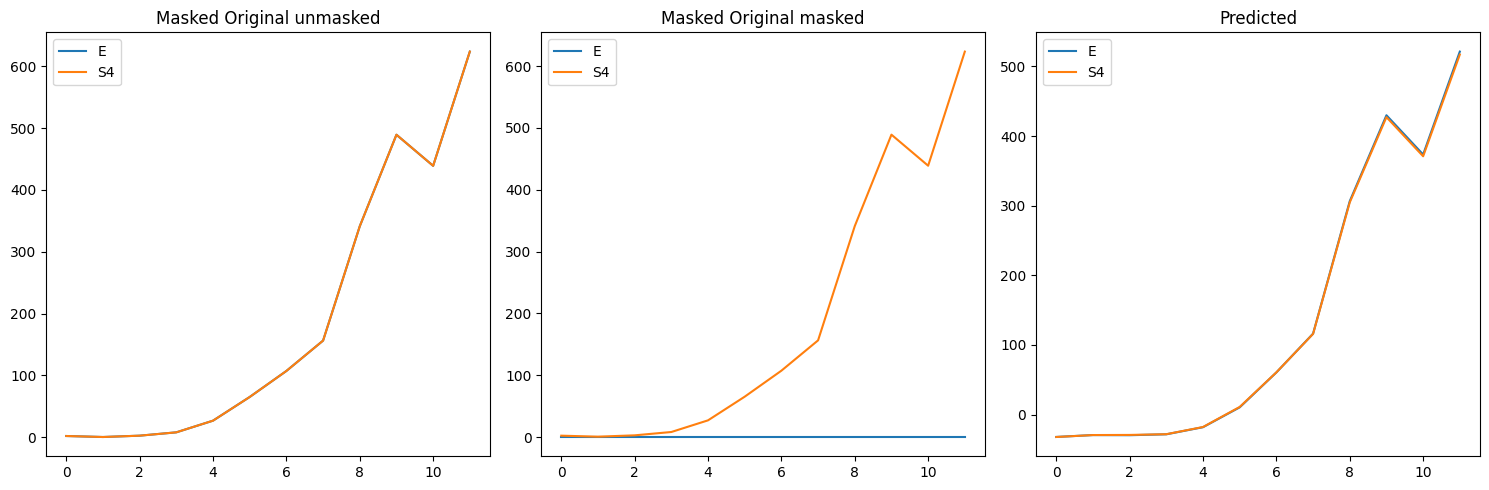

In [299]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[rand_idx: rand_idx + HIST_STEPS,:]
DATA_RAW_SIMULATION_T = torch.tensor(DATA_RAW_SIMULATION.values)

SIM_DS = SlidingWindowSensorDataset(DATA_RAW_SIMULATION_T, LEAF_INDICES, HIST_STEPS)  
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)


X_masked, X_unmasked,_ = next(iter((SIM_DL)))
print(f"X_masked: {X_masked.shape}")

MODEL.eval()
with torch.no_grad():
    Y_pred = MODEL(x=X_masked, adj_mask=ATT_MASK_T)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pd.DataFrame(X_unmasked[0].T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[0], title='Masked Original unmasked')
pd.DataFrame(X_masked[0].T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[1], title='Masked Original masked')
pd.DataFrame(Y_pred[0].detach().T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[2], title='Predicted')
plt.tight_layout()
plt.show()


<Axes: >

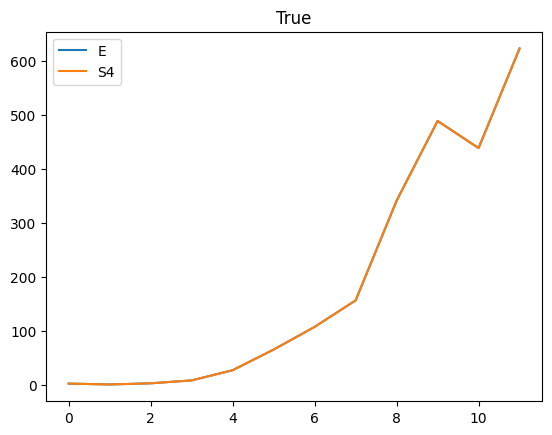

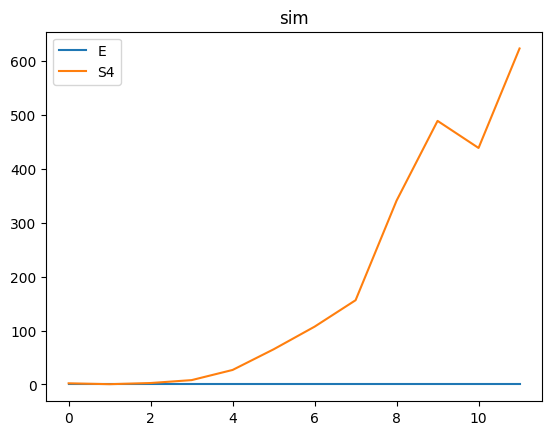

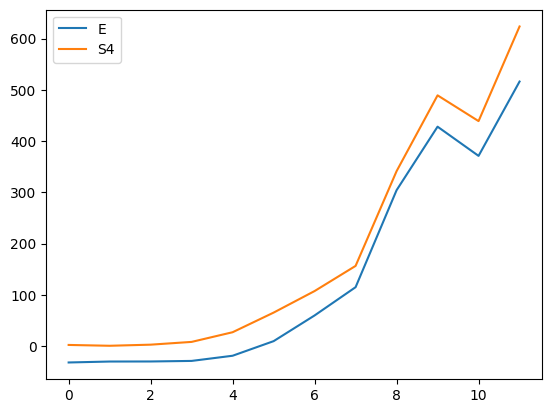

In [300]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[rand_idx: rand_idx + HIST_STEPS,:]
DATA_RAW_SIMULATION_T = torch.tensor(DATA_RAW_SIMULATION.copy().values).float()

data_simulation = DATA_RAW_SIMULATION_T
data_simulation_true = data_simulation.clone()
pd.DataFrame(data_simulation_true.numpy(), columns=NODE_LIST)[['E','S4']].plot(title='True')


data_simulation[:,INNER_NODES_MASK_BOOL] = 0
pd.DataFrame(data_simulation.numpy(), columns=NODE_LIST)[['E','S4']].plot(title='sim')


LEAF_MASK = LEAF_NODES_MASK.astype(bool).values

PLOTS_ARR = []
PREDS = []
for i in range((HIST_STEPS)):

    with torch.no_grad():
        _pred = MODEL(x=data_simulation.T, adj_mask=ATT_MASK_T)
    

        _pred_last = _pred[0].T
        PREDS.append(_pred_last[i].numpy())

        data_simulation[i,INNER_NODES_MASK_BOOL] = _pred_last[i,INNER_NODES_MASK_BOOL]
        data_simulation[i,~INNER_NODES_MASK_BOOL] = data_simulation_true[i,~INNER_NODES_MASK_BOOL]

        PLOTS_ARR.append(data_simulation.clone().numpy())
    


    #if i == 5:
    #    break

pd.DataFrame(data_simulation.numpy(), columns=NODE_LIST)[['E','S4']].plot()

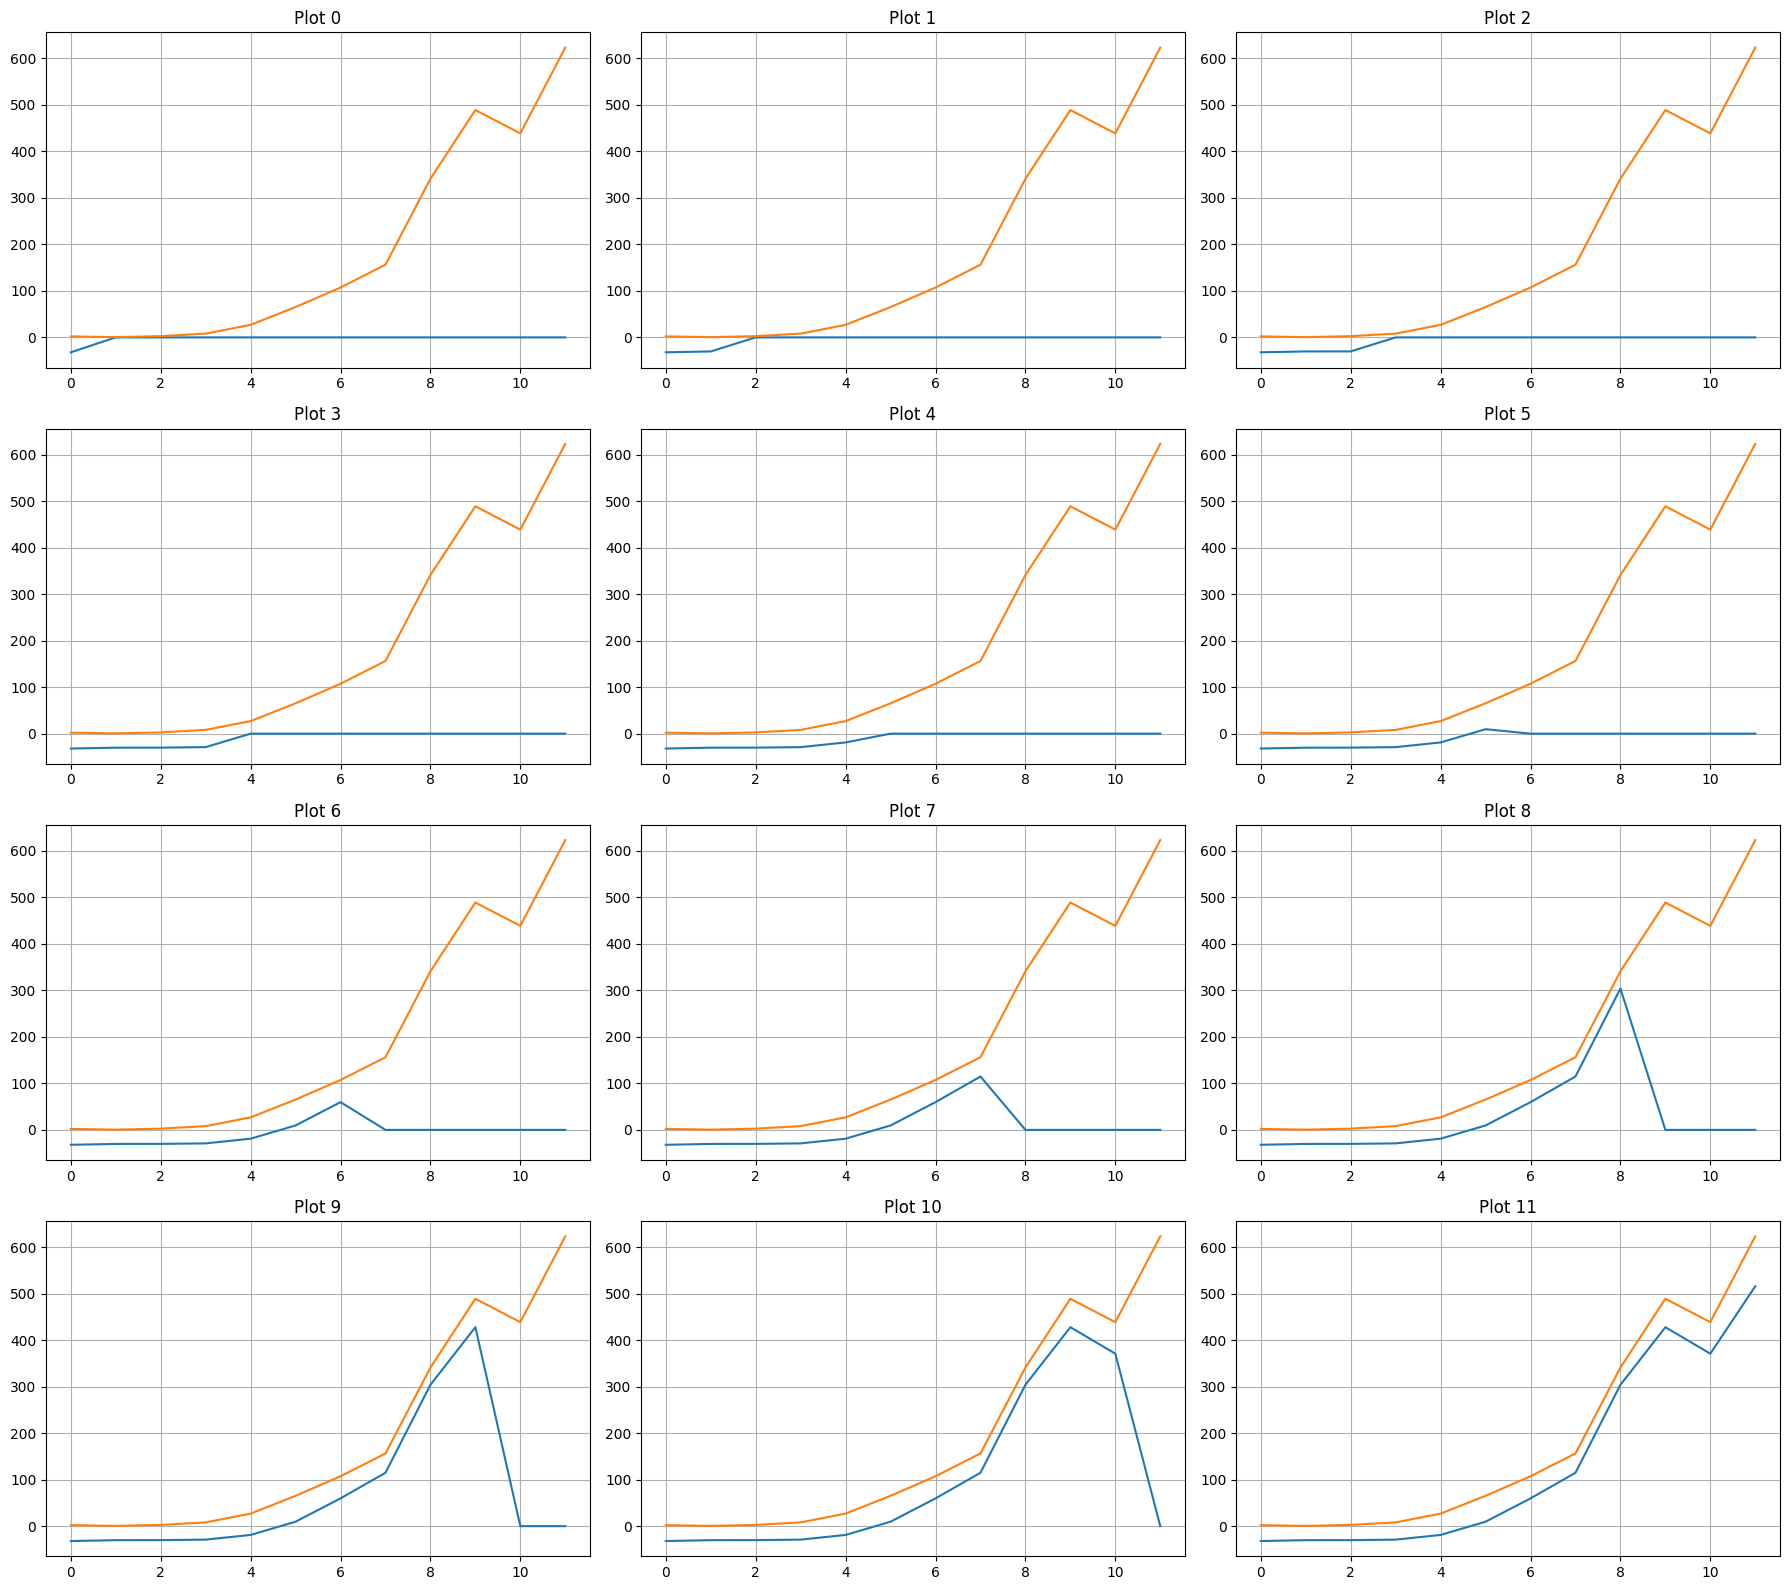

In [301]:
show_plots_grid(PLOTS_ARR)

### SCENARIO: DROP 50%

X_masked: torch.Size([1, 16, 12])


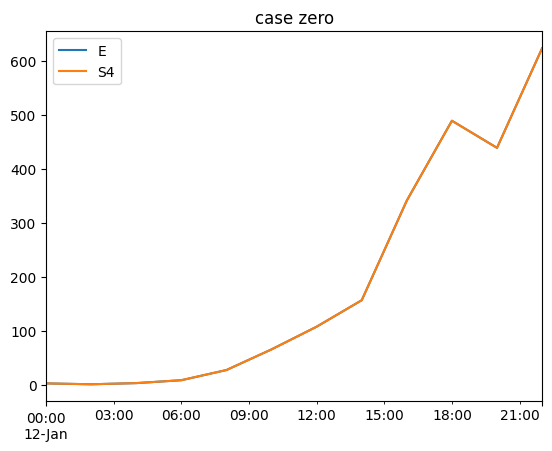

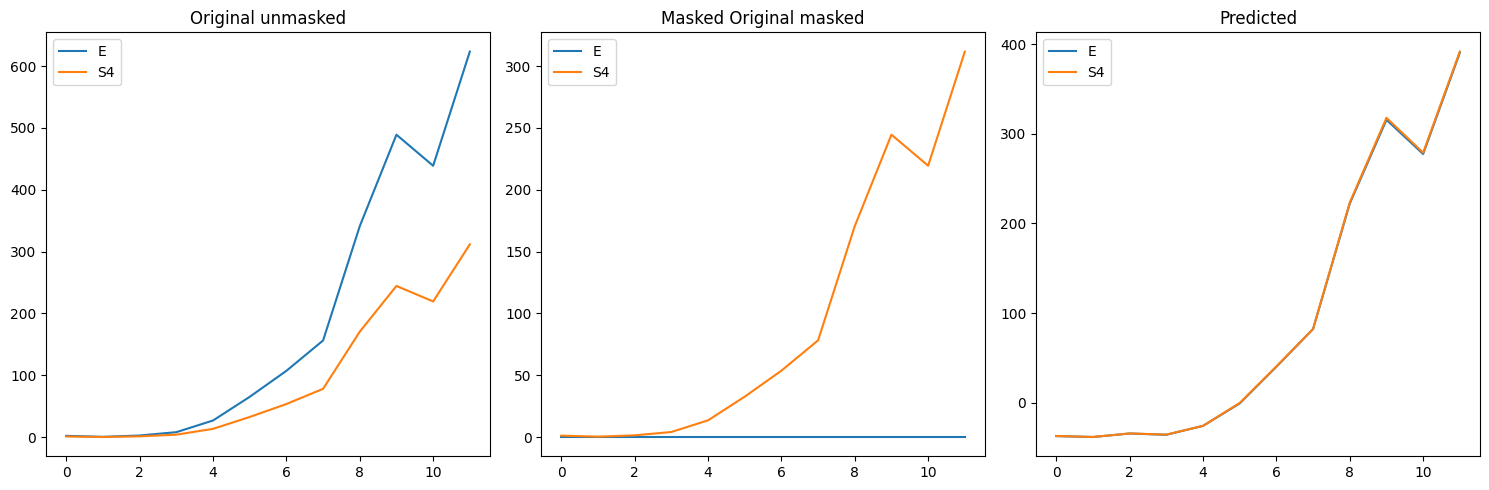

In [302]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[rand_idx: rand_idx + HIST_STEPS,:]
DATA_RAW_SIMULATION[['E','S4']].plot(title='case zero')
DATA_RAW_SIMULATION['S4'] *= .5
DATA_RAW_SIMULATION_T = torch.tensor(DATA_RAW_SIMULATION.values).float()



SIM_DS = SlidingWindowSensorDataset(DATA_RAW_SIMULATION_T, LEAF_INDICES, HIST_STEPS)  
SIM_DL = DataLoader(SIM_DS, batch_size=BATCH_SIZE, shuffle=False)

X_masked, X_unmasked,_ = next(iter((SIM_DL)))
print(f"X_masked: {X_masked.shape}")

MODEL.eval()
with torch.no_grad():
    Y_pred = MODEL(x=X_masked, adj_mask=ATT_MASK_T)



fig, axes = plt.subplots(1, 3, figsize=(15, 5))
pd.DataFrame(X_unmasked[0].T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[0], title='Original unmasked')
pd.DataFrame(X_masked[0].T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[1], title='Masked Original masked')
pd.DataFrame(Y_pred[0].detach().T.numpy(), columns=NODE_LIST)[['E','S4']].plot(ax=axes[2], title='Predicted')
plt.tight_layout()
plt.show()






<Axes: >

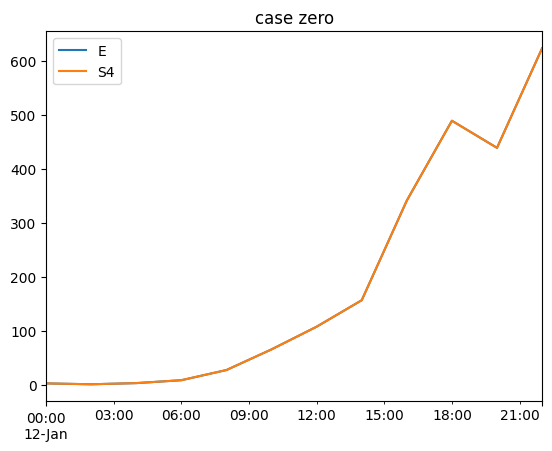

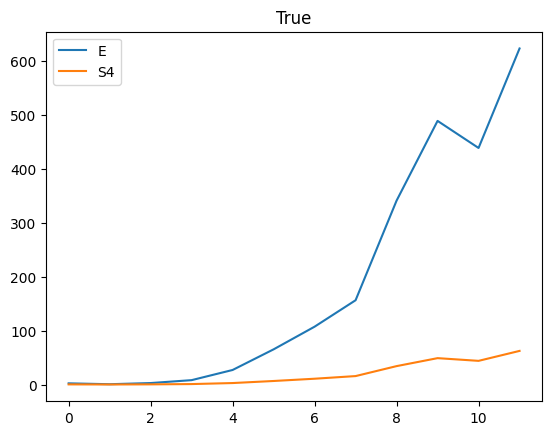

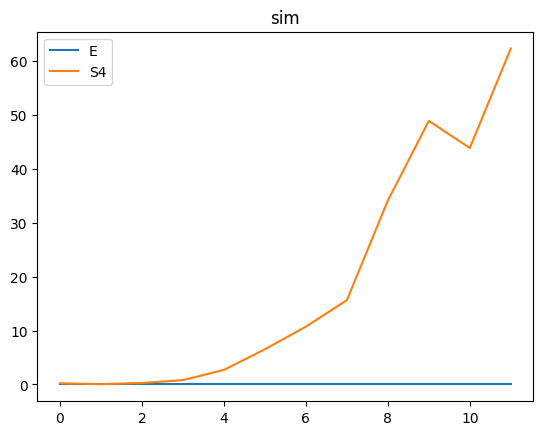

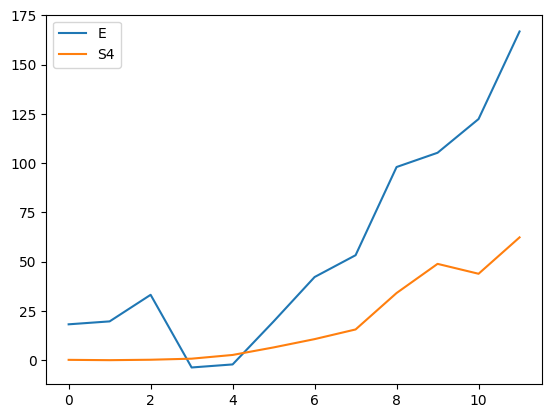

In [303]:
DATA_RAW_SIMULATION = DATA_RAW_MODEL.copy()
DATA_RAW_SIMULATION = DATA_RAW_SIMULATION.iloc[rand_idx: rand_idx + HIST_STEPS,:]
DATA_RAW_SIMULATION[['E','S4']].plot(title='case zero')
DATA_RAW_SIMULATION['S4'] *= .1
DATA_RAW_SIMULATION_T = torch.tensor(DATA_RAW_SIMULATION.values).float()

data_simulation = DATA_RAW_SIMULATION_T
data_simulation_true = data_simulation.clone()
pd.DataFrame(data_simulation_true.numpy(), columns=NODE_LIST)[['E','S4']].plot(title='True')


data_simulation[:,INNER_NODES_MASK_BOOL] = 0
pd.DataFrame(data_simulation.numpy(), columns=NODE_LIST)[['E','S4']].plot(title='sim')


LEAF_MASK = LEAF_NODES_MASK.astype(bool).values

PLOTS_ARR = []
PREDS = []
for i in range((HIST_STEPS)):

    with torch.no_grad():
        _pred = MODEL(x=data_simulation.T, adj_mask=ATT_MASK_T)
    

        _pred_last = _pred[0].T
        PREDS.append(_pred_last[i].numpy())

        data_simulation[i,INNER_NODES_MASK_BOOL] = _pred_last[i,INNER_NODES_MASK_BOOL]
        data_simulation[i,~INNER_NODES_MASK_BOOL] = data_simulation_true[i,~INNER_NODES_MASK_BOOL]

        PLOTS_ARR.append(data_simulation.clone().numpy())
    


    #if i == 5:
    #    break

pd.DataFrame(data_simulation.numpy(), columns=NODE_LIST)[['E','S4']].plot()

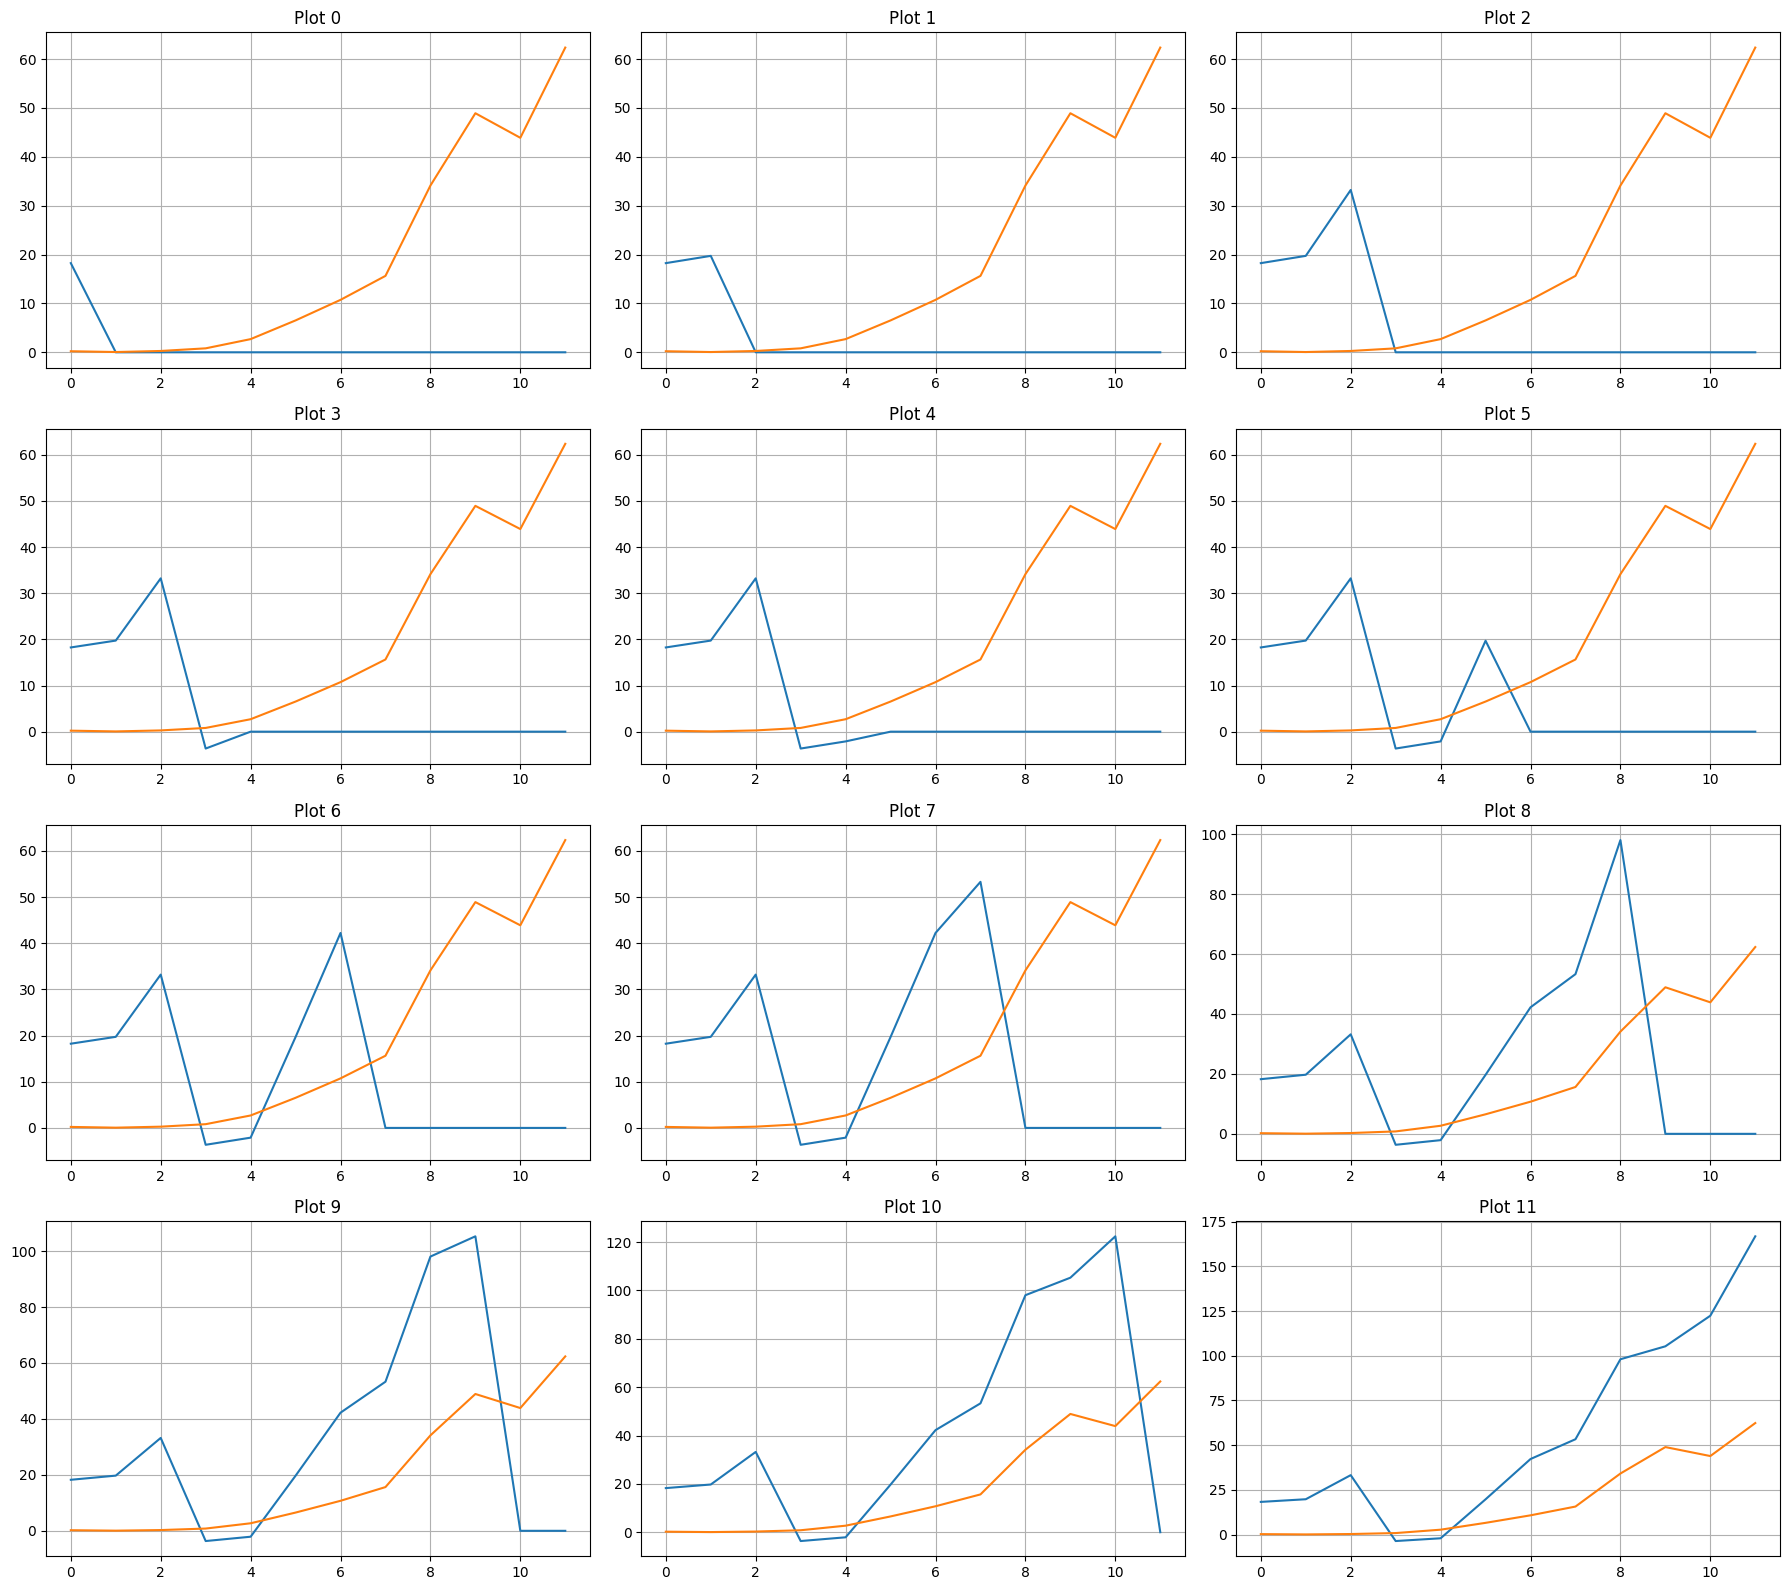

In [304]:
show_plots_grid(PLOTS_ARR)
